# Inter-scanner variability of FC matrices

In [1]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

Loading required package: lpSolve



## Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030).

In [2]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths

# Define filtering parameters
metric = "sparseinversecovariance"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)       
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

# Load files
entities_base = {
    "subject": "001",
    "task": "rest",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}
# Get functional connectivity files
files = layout.get(**entities_base, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files) == 36, f"Expected 36 FC matrices, got {len(files)}"
df_fc = pd.DataFrame({"filename": files, "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)
df_fc["order"] = df_fc["session"].str[4:5].astype(int)
')

In [3]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
head(df_fc)

,filename,subject,session,scanner,repetition,order
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,/data/derivatives/hcph-fc/sub-001/ses-20101060/func/sub-001_ses-20101060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20101060,prisma,1,1
2,/data/derivatives/hcph-fc/sub-001/ses-20102030/func/sub-001_ses-20102030_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20102030,vidafit,1,2
3,/data/derivatives/hcph-fc/sub-001/ses-20103034/func/sub-001_ses-20103034_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20103034,vida,1,3
4,/data/derivatives/hcph-fc/sub-001/ses-20201060/func/sub-001_ses-20201060_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20201060,prisma,2,1
5,/data/derivatives/hcph-fc/sub-001/ses-20202030/func/sub-001_ses-20202030_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20202030,vidafit,2,2
6,/data/derivatives/hcph-fc/sub-001/ses-20203034/func/sub-001_ses-20203034_task-rest_scale-64_fdthresh-05_meas-sparseinversecovariance_connectivity.tsv,001,20203034,vida,2,3


## Repeated-measures MANOVA
### Prepare the dataframe for inputting into rm-MANOVA

We add each value from the upper triangle of the functional connectivity (FC) matrix as a separate column in the dataframe. Since the FC matrix is symmetric, retaining only the upper triangle is sufficient. This transformation is necessary because the implementation of repeated-measures MANOVA (rm-MANOVA) requires each variable to be explicitly specified as a column to write the formula determining the dependent and independent variables of the model.

In [4]:
# Load all FC matrices and add them flattened to the dataframe
for (i in seq_len(nrow(df_fc))) {
    tsv_file <- df_fc$filename[i]
    mat <- as.matrix(read.table(tsv_file, header = FALSE, sep = "\t"))
    if (grepl("sparseinversecovariance", tsv_file)) {
        # Negate the precision matrix to get partial correlations
        mat <- -mat
    }
    # Flatten the upper triangle of the matrix (excluding diagonal)
    flat <- mat[upper.tri(mat, diag = FALSE)]
    col_names <- paste0("edge", seq_along(flat))
    # Add values to the dataframe
    for (j in seq_along(flat)) {
        df_fc[i, col_names[j]] <- flat[j]
    }
}
# Remove the filename column as it is no longer needed
df_fc$filename <- NULL

df_fc$scanner <- as.factor(df_fc$scanner)
df_fc$repetition <- as.factor(df_fc$repetition)
df_fc$order <- as.factor(df_fc$order)
head(df_fc)

,subject,session,scanner,repetition,order,edge1,edge2,edge3,edge4,edge5,⋯,edge1882,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891
,<chr>,<chr>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,001,20101060,prisma,1,1,5.713746e-07,6.540584e-07,7.533472e-02,7.260873e-02,-6.969980e-07,⋯,-7.589415e-18,-2.301706e-17,-4.420834e-17,-9.459664e-17,3.980266e-02,-2.027458e-17,2.348138e-17,1.734723e-18,4.349188e-02,5.167582e-17
2,001,20102030,vidafit,1,2,-3.001827e-06,-8.633434e-07,7.434885e-03,6.236161e-02,-2.234694e-06,⋯,-1.006140e-16,-1.252525e-16,-3.995963e-17,-3.835365e-18,1.313193e-01,1.972221e-17,5.607677e-17,-1.649754e-17,3.675526e-18,-1.750475e-18
3,001,20103034,vida,1,3,6.528042e-06,7.514955e-06,6.689939e-02,7.235371e-06,-7.886987e-07,⋯,-3.903128e-16,9.413585e-17,-2.438371e-16,0.000000e+00,1.557758e-01,-1.322727e-16,-1.104921e-16,1.066855e-16,3.918115e-02,-1.469841e-16
4,001,20201060,prisma,2,1,3.904534e-07,1.515389e-06,3.453112e-06,-1.415896e-05,-2.232815e-07,⋯,-2.295798e-17,3.557305e-17,1.848350e-17,-3.483355e-17,-6.859457e-17,1.501620e-17,-1.430277e-16,-4.933120e-17,2.647703e-03,-3.850324e-17
5,001,20202030,vidafit,2,2,-1.454936e-06,-1.157484e-06,9.403329e-03,2.148322e-05,-1.280872e-06,⋯,4.530888e-02,-7.994925e-17,-2.787828e-17,-8.960982e-17,9.983821e-02,3.426079e-17,-1.062243e-16,1.301043e-17,1.928596e-02,4.744856e-17
6,001,20203034,vida,2,3,-4.514564e-06,2.766009e-02,1.460895e-05,4.672855e-04,-4.646385e-06,⋯,4.049618e-02,-1.033938e-16,5.771188e-17,-1.590655e-16,-4.655646e-17,-1.710574e-16,-8.704852e-17,1.002208e-16,-7.124293e-17,-2.062372e-17


### Construct the formula by concatenating the column names that correspond to edge value

In [5]:
#Construct formula
dep_var <- ''
col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[c(-1,-2,-3, -4, -5)]
for (key in edge_keys){
    dep_var <- paste(dep_var, sprintf('%s +',key))
}
dep_var = substring(dep_var,1, nchar(dep_var)-2)

my_formula <- as.formula(paste(dep_var, " ~ scanner"))
my_formula

edge1 + edge2 + edge3 + edge4 + edge5 + edge6 + edge7 + edge8 + 
    edge9 + edge10 + edge11 + edge12 + edge13 + edge14 + edge15 + 
    edge16 + edge17 + edge18 + edge19 + edge20 + edge21 + edge22 + 
    edge23 + edge24 + edge25 + edge26 + edge27 + edge28 + edge29 + 
    edge30 + edge31 + edge32 + edge33 + edge34 + edge35 + edge36 + 
    edge37 + edge38 + edge39 + edge40 + edge41 + edge42 + edge43 + 
    edge44 + edge45 + edge46 + edge47 + edge48 + edge49 + edge50 + 
    edge51 + edge52 + edge53 + edge54 + edge55 + edge56 + edge57 + 
    edge58 + edge59 + edge60 + edge61 + edge62 + edge63 + edge64 + 
    edge65 + edge66 + edge67 + edge68 + edge69 + edge70 + edge71 + 
    edge72 + edge73 + edge74 + edge75 + edge76 + edge77 + edge78 + 
    edge79 + edge80 + edge81 + edge82 + edge83 + edge84 + edge85 + 
    edge86 + edge87 + edge88 + edge89 + edge90 + edge91 + edge92 + 
    edge93 + edge94 + edge95 + edge96 + edge97 + edge98 + edge99 + 
    edge100 + edge101 + edge102 + edge103 + edge104 

### Run the rm-MANOVA

In [6]:
fit <- multRM(my_formula, data = df_fc, subject = 'session', within = 'scanner')
summary(fit)

ERROR: Error in prepare.data(formula, data, subject, within): The number of subjects (36) times the 
  number of within-subject factor levels (3) does not equal
  the total number of observations (36). 
  Check for missing values in the data.


## Intra-class correlation coefficient (ICC) to quantify between-scanner variability

In [7]:
icc_results <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_fc[, c( "scanner", edge)]
    df_icc <- pivot_wider(df_icc, names_from = scanner, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(prisma, vida, vidafit))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_results <- rbind(icc_results, data.frame(edge = edge, ICC = icc_val))
}
head(df_icc)
head(icc_results)

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(edge)

  # Now:
  data %>% select(all_of(edge))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


prisma,vidafit,vida
<dbl>,<dbl>,<dbl>
5.167582e-17,-1.750475e-18,-1.469841e-16
-3.850324e-17,4.744856e-17,-2.062372e-17
1.681766e-17,5.344078e-18,1.076156e-16
-1.098919e-16,1.718209e-17,1.452872e-17
1.035807e-02,-5.010170e-17,6.270949e-17
-7.349301e-17,-1.836159e-16,-8.626545e-17


,edge,ICC
,<chr>,<dbl>
1,edge1,-0.0172390994
2,edge2,-0.0469087433
3,edge3,-0.0234311629
4,edge4,-0.1738795027
5,edge5,-0.0539968901
6,edge6,-0.0003582582


Mean ICC across edges: -0.02419042 
Median ICC across edges: -0.01757463 


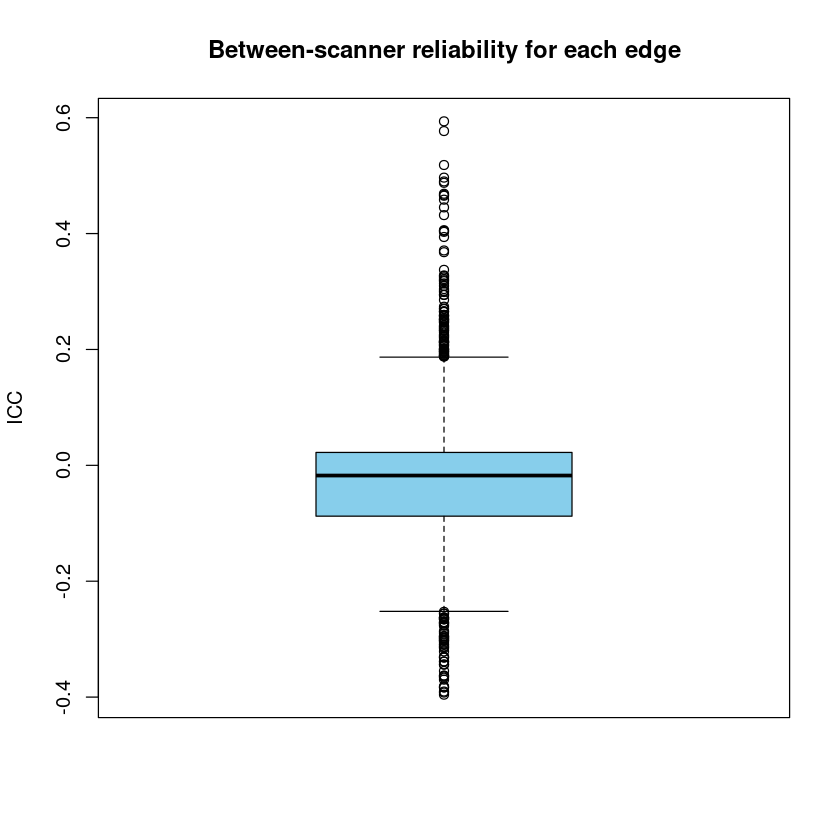

In [23]:
mean_icc <- mean(icc_results$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_results$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_results$ICC, main = "Between-scanner reliability for each edge", ylab = "ICC", col = "skyblue")

In [62]:
icc_results <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

for (rep in df_fc$repetition) {
    df_rep <- df_fc[df_fc$repetition == rep, ]
    # Keep only the edge and session columns
    colnames <- df_rep$scanner
    df_rep <- t(df_rep[, edge_keys])
    colnames(df_rep) <- colnames
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
    icc_results <- rbind(icc_results, data.frame(edge = edge, ICC = icc_val))
}
head(df_rep)
icc_results

,vidafit,vida,prisma
edge1,-1.052766e-06,-1.245544e-05,-1.738165e-06
edge2,-1.828220e-06,8.131475e-06,-1.091652e-06
edge3,1.497237e-01,-2.167989e-05,1.356319e-05
edge4,1.552997e-01,1.151996e-05,6.414071e-02
edge5,-3.903089e-07,-7.215465e-06,4.221924e-07
edge6,-1.300343e-06,5.341054e-06,3.592163e-07


edge,ICC
<chr>,<dbl>
edge1891,0.7922871
edge1891,0.7922871
edge1891,0.7922871
edge1891,0.7646605
edge1891,0.7646605
edge1891,0.7646605
edge1891,0.7716107
edge1891,0.7716107
edge1891,0.7716107


Mean ICC across edges: 0.781667 
Quantiles (25%, median, 75%): 0.766634 0.7782696 0.7919817 


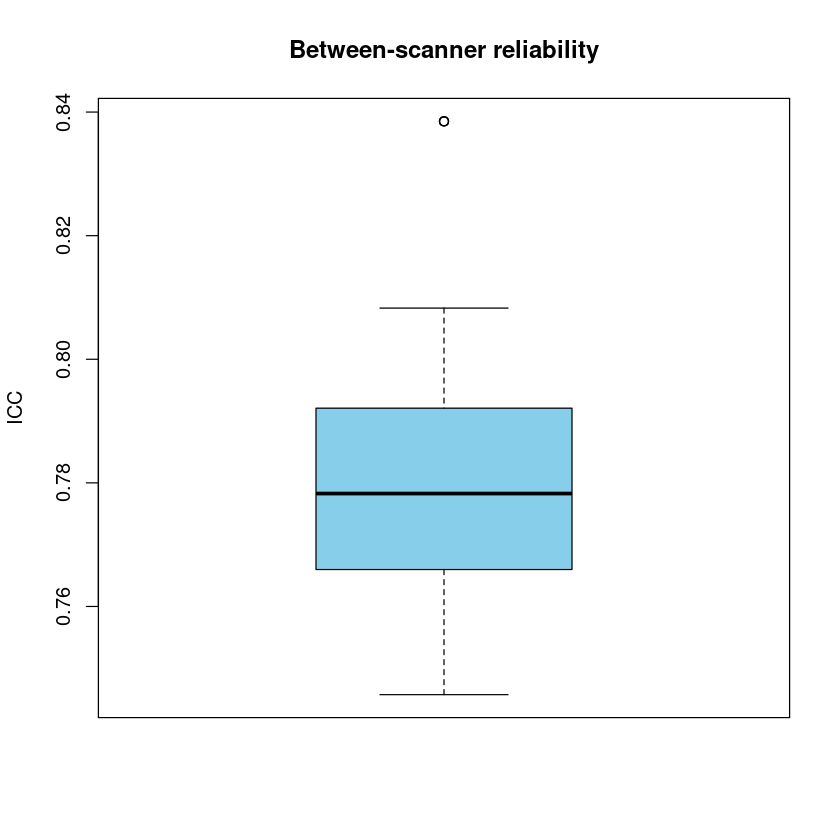

In [67]:
mean_icc <- mean(icc_results$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_results$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

boxplot(icc_results$ICC, main = "Between-scanner reliability", ylab = "ICC", col = "skyblue")

## ICC to quantify intra-scanner variability

Let's quantify the intra-scanner reliability of FC estimates when using the standard fixation cross task for resting-state.

In [ ]:
for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    df_scanner <- t(df_scanner[, edge_keys])
    icc_val <- icc(df_scanner, model = "twoway", type = "agreement", unit = "single")$value
    cat(sprintf("ICC of for %s scanner: %.4f\n", scanner, icc_val))
}
head(df_scanner)

ICC for prisma scanner: 0.7800
ICC for vidafit scanner: 0.7962
ICC for vida scanner: 0.8155


,3,6,8,11,14,16,19,23,27,30,31,35
edge1,6.528042e-06,-4.514564e-06,-8.506657e-06,-3.215814e-06,-5.611867e-06,-1.163362e-06,-1.055886e-06,9.467434e-07,3.087218e-06,1.113368e-06,-4.712413e-06,-1.245544e-05
edge2,7.514955e-06,2.766009e-02,-4.268188e-06,-1.695434e-06,-9.683560e-07,3.029625e-06,-9.775773e-06,-1.016135e-06,7.646137e-07,-4.235880e-06,-6.342809e-06,8.131475e-06
edge3,6.689939e-02,1.460895e-05,9.157005e-02,9.144441e-02,3.725246e-03,1.416232e-01,9.480423e-08,4.164482e-02,1.045742e-02,-4.391880e-06,8.693893e-02,-2.167989e-05
edge4,7.235371e-06,4.672855e-04,1.805981e-02,6.709116e-02,6.825498e-02,5.305358e-02,4.791103e-02,1.185077e-02,-2.287152e-05,2.343900e-05,9.511922e-03,1.151996e-05
edge5,-7.886987e-07,-4.646385e-06,-4.847092e-06,-7.981107e-07,1.155399e-07,-1.123034e-06,7.750204e-07,-9.281694e-09,1.307680e-06,-1.880596e-06,6.730842e-08,-7.215465e-06
edge6,7.797121e-06,-2.661734e-07,-1.059137e-06,-1.370371e-06,-2.018452e-06,1.328749e-07,-2.814641e-07,-2.565683e-07,-3.477949e-07,-1.781178e-06,-2.678140e-09,5.341054e-06
